# 02 - Forecasting
## Train sales forecasting models, compare models, evaluate metrics, register best model

Each notebook handles its own preprocessing and feature engineering.
Shared utilities are in `notebooks/utils/`.

In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import warnings
from pathlib import Path
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error,
    explained_variance_score,
    max_error,
)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, str(Path.cwd() / 'notebooks'))
from utils.data import load_transactions, load_products,load_causal_data, DATA_DIR, ARTIFACTS_DIR
from utils.features import (
    add_calendar_features, add_lag_features, add_rolling_features,
    add_discount_features
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

# ============================================================
# CONFIGURATION
# ============================================================
REPROCESS = True

ARTIFACT_DIR = ARTIFACTS_DIR / 'forecasting'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = ARTIFACT_DIR / 'features.parquet'
TARGET_PATH = ARTIFACT_DIR / 'target.npy'
FEATURE_COLS_PATH = ARTIFACT_DIR / 'feature_cols.json'
SPLIT_PATH = ARTIFACT_DIR / 'split_indices.pkl'
MODEL_PATH = ARTIFACT_DIR.parent.parent / 'models' / 'forecast_model.pkl'
META_PATH = ARTIFACT_DIR.parent.parent / 'models' / 'forecast_model_meta.json'

print(f'REPROCESS = {REPROCESS}')
print(f'Artifacts directory: {ARTIFACT_DIR}')

REPROCESS = True
Artifacts directory: /home/mhseddighi/Projects/promotion-intelligence/artifacts/forecasting


## Load or Build Features

When REPROCESS=True: load raw data, build features from scratch, save artifacts.
When REPROCESS=False: load pre-built feature artifacts.

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import json
import joblib


print("=== Building features ===")

transactions = load_transactions()
products = load_products()
causal = load_causal_data()

# OPTIMIZATION 1: Merge efficiently with minimal columns
# Only select needed columns early to reduce memory footprint
df = (
    transactions[["PRODUCT_ID", "STORE_ID", "DAY", "QUANTITY", 
                    "SALES_VALUE", "RETAIL_DISC", "COUPON_DISC"]]
    .merge(
        products[["PRODUCT_ID", "DEPARTMENT"]], 
        on="PRODUCT_ID", 
        how="left"
    )
    .merge(
        causal[["PRODUCT_ID", "display", "mailer"]],
        on="PRODUCT_ID",
        how="left"
    )
)

# OPTIMIZATION 2: Sort in-place to avoid copy
df.sort_values(
    ["PRODUCT_ID", "STORE_ID", "DAY"],
    inplace=True
)


=== Building features ===


In [ ]:

# OPTIMIZATION 3: Group before dropping PRODUCT_ID to use it if needed
# Removed "DEPARTMENT" typo (was "DEPARTMENT")
df = df.groupby(
    ["DEPARTMENT", "DAY"],
    as_index=False,
    sort=False  # Avoid unnecessary sorting
).agg(
    {
        "QUANTITY": "sum",
        "SALES_VALUE": "sum",
        "RETAIL_DISC": "sum",
        "COUPON_DISC": "sum",
        "display": "max",
        "mailer": "first"
    }
)

print(f"Departments before filtering: {df['DEPARTMENT'].nunique()}")

# OPTIMIZATION 4: Filter early to reduce data for subsequent operations
df = df[df["QUANTITY"] >= 10]
print(f"Departments after filtering (>=10 quantity): {df['DEPARTMENT'].nunique()}")
print(f"Rows after filtering: {len(df):,}")

# -----------------------------
# Encode categorical features
# -----------------------------

categorical_cols = ["DEPARTMENT", "mailer"]
encoders = {}

# OPTIMIZATION 5: Encode with less memory overhead
for col in categorical_cols:
    encoder = LabelEncoder()
    # Convert to category type first for memory efficiency
    df[col] = df[col].astype(str).astype('category')
    df[col] = encoder.fit_transform(df[col])
    encoders[col] = encoder

# -----------------------------
# Feature engineering
# -----------------------------
# OPTIMIZATION 6: Chain operations to avoid intermediate copies
df = add_calendar_features(df, day_col="DAY")
df = add_discount_features(df)

# OPTIMIZATION 7: Calculate lags and rolling features efficiently
# Consider using shift() and rolling() with transform for better performance
lag_windows = [1, 7, 14, 28]
rolling_windows = [7, 14, 28]

df = add_lag_features(
    df,
    group_col="DEPARTMENT",
    value_col="QUANTITY",
    lags=lag_windows
)

df = add_rolling_features(
    df,
    group_col="DEPARTMENT",
    value_col="QUANTITY",
    windows=rolling_windows
)

# OPTIMIZATION 8: Remove rows without history efficiently
df.dropna(inplace=True)


In [ ]:

# -----------------------------
# Prepare X and y
# -----------------------------

drop_cols = [
    "QUANTITY",
    "SALES_VALUE", 
    "DAY",
    "PRODUCT_ID",
    "DEPARTMENT", 
    "STORE_ID",
    "WEEK_NO",
]

# OPTIMIZATION 9: Only include columns that actually exist
feature_cols = [
    c for c in df.columns 
    if c not in drop_cols
]

# OPTIMIZATION 10: Use .values for numpy array to reduce memory
X = df[feature_cols].copy()  # Create explicit copy
y = df["QUANTITY"].values

# -----------------------------
# Time split
# -----------------------------

# OPTIMIZATION 11: Convert DAY to numpy for faster operations
day_values = df["DAY"].values
split_day = np.quantile(day_values, 0.8)

train_idx = day_values <= split_day
test_idx = day_values > split_day

X_train = X.loc[train_idx]
X_test = X.loc[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

print(f"Features: {len(feature_cols)}")
print(f"Train: {len(X_train)}")
print(f"Test: {len(X_test)}")

# OPTIMIZATION 12: Save efficiently
X.to_parquet(FEATURES_PATH, index=False, compression='snappy')
np.save(TARGET_PATH, y)

with open(FEATURE_COLS_PATH, "w") as f:
    json.dump(feature_cols, f)

# OPTIMIZATION 13: Store indices as boolean arrays for memory efficiency
joblib.dump(
    {
        "train_idx": np.where(train_idx)[0],
        "test_idx": np.where(test_idx)[0],
        "encoders": encoders
    },
    SPLIT_PATH
)


In [14]:
df.head()

,PRODUCT_ID,STORE_ID,DEPARTMENT,DAY,WEEK_NO,QUANTITY,SALES_VALUE,RETAIL_DISC,COUPON_DISC,display,...,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_28,rolling_std_28
0,25671,3191,GROCERY,410,59,4,13.96,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.00000,0.0,0.00000
1,25671,3266,GROCERY,247,36,1,3.49,0.0,0.0,0,...,4.0,0.0,0.0,0.0,4.0,0.00000,4.0,0.00000,4.0,0.00000
2,25671,3313,GROCERY,157,23,1,3.49,0.0,0.0,0,...,1.0,0.0,0.0,0.0,2.5,2.12132,2.5,2.12132,2.5,2.12132
3,26081,3235,MISC. TRANS.,250,36,1,0.99,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.00000,0.0,0.00000
4,26093,33904,PASTRY,458,66,1,1.59,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.00000,0.0,0.00000


In [15]:
df.describe()

,PRODUCT_ID,STORE_ID,DAY,WEEK_NO,QUANTITY,SALES_VALUE,RETAIL_DISC,COUPON_DISC,display,mailer,...,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_28,rolling_std_28
count,2.540839e+06,2.540839e+06,2.540839e+06,2.540839e+06,2.540839e+06,2.540839e+06,2.540839e+06,2.540839e+06,2.540839e+06,2.540839e+06,...,2.540839e+06,2.540839e+06,2.540839e+06,2.540839e+06,2.540839e+06,2.540839e+06,2.540839e+06,2.540839e+06,2.540839e+06,2.540839e+06
mean,2.888255e+06,3.146325e+03,3.885825e+02,5.619698e+01,1.025988e+02,3.171719e+00,-5.507576e-01,-1.273261e-02,4.917502e-01,6.631171e+00,...,1.025953e+02,1.025447e+02,1.024735e+02,1.023656e+02,1.025758e+02,5.562835e+01,1.025571e+02,5.787238e+01,1.025253e+02,5.941191e+01
std,3.853695e+06,8.941649e+03,1.898563e+02,2.712157e+01,1.546282e+03,4.896418e+00,1.306040e+00,1.732492e-01,1.688659e+00,2.720496e+00,...,1.546272e+03,1.545841e+03,1.545099e+03,1.544072e+03,1.358547e+03,7.950832e+02,1.341492e+03,7.949096e+02,1.331500e+03,7.964875e+02
min,2.567100e+04,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-1.800000e+02,-5.593000e+01,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.164820e+05,3.300000e+02,2.290000e+02,3.300000e+01,1.000000e+00,1.290000e+00,-6.900000e-01,0.000000e+00,0.000000e+00,8.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.071429e+00,2.672612e-01,1.071429e+00,2.622653e-01
50%,1.026945e+06,3.720000e+02,3.900000e+02,5.600000e+01,1.000000e+00,2.090000e+00,-2.000000e-02,0.000000e+00,0.000000e+00,8.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.142857e+00,3.779645e-01,1.142857e+00,3.922323e-01,1.178571e+00,4.483951e-01
75%,1.132770e+06,4.220000e+02,5.530000e+02,8.000000e+01,1.000000e+00,3.490000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.428571e+00,5.345225e-01,1.428571e+00,6.462062e-01,1.428571e+00,7.373268e-01
max,1.831630e+07,3.428000e+04,7.110000e+02,1.020000e+02,1.225830e+05,8.400000e+02,3.990000e+00,0.000000e+00,9.000000e+00,1.000000e+01,...,1.225830e+05,1.225830e+05,1.225830e+05,1.225830e+05,4.730314e+04,4.282222e+04,4.140236e+04,3.058152e+04,3.583996e+04,2.399589e+04


In [5]:
zero_sparsity = (features['coupon_disc_abs'] == 0).mean() * 100
print("Zero values per column (%):")
print(zero_sparsity)

Zero values per column (%):
69.82094288304623


## Train and Compare Models

In [16]:
# Train Random Forest
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)

# Predict
preds = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
mape = mean_absolute_percentage_error(y_test, preds) * 100
medae = median_absolute_error(y_test, preds)
evs = explained_variance_score(y_test, preds)
maxerr = max_error(y_test, preds)

print("=" * 50)
print("Random Forest Results")
print("=" * 50)
print(f"MAE                 : {mae:.3f}")
print(f"RMSE                : {rmse:.3f}")
print(f"R²                  : {r2:.4f}")
print(f"MAPE                : {mape:.2f}%")
print(f"Median Absolute Err.: {medae:.3f}")
print(f"Explained Variance  : {evs:.4f}")
print(f"Max Error           : {maxerr:.3f}")

trained_model = model

ValueError: could not convert string to float: 'GROCERY'

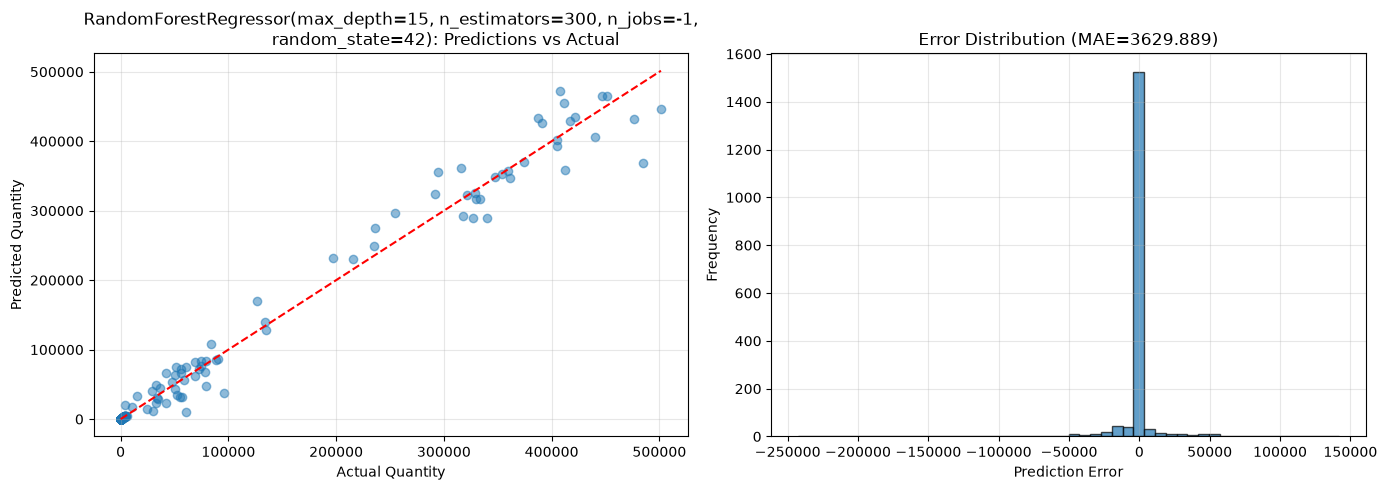

In [59]:
# Plot predictions vs actual
y_pred = trained_model.predict(X_test)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test[:500], y_pred[:500], alpha=0.5)
plt.plot([0, y_test[:500].max()], [0, y_test[:500].max()], 'r--')
plt.xlabel('Actual Quantity')
plt.ylabel('Predicted Quantity')
plt.title(f'{trained_model}: Predictions vs Actual')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
errors = y_test - y_pred
plt.hist(errors, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title(f'Error Distribution (MAE={mae:.3f})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [60]:
# Save best model to models/ (where backend loads from)
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(trained_model, MODEL_PATH)

with open(META_PATH, 'w') as f:
    json.dump({
        'model_type': 'randomforest',
        'feature_cols': feature_cols,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'n_samples': len(X_train),
    }, f)

print(f'Model saved to {MODEL_PATH}')
print(f'Metadata saved to {META_PATH}')

# Verify model can be loaded
loaded = joblib.load(MODEL_PATH)
test_pred = loaded.predict(X_test[:5])
print('Verification - predictions:', test_pred)

Model saved to /home/mhseddighi/Projects/promotion-intelligence/models/forecast_model.pkl
Metadata saved to /home/mhseddighi/Projects/promotion-intelligence/models/forecast_model_meta.json
Verification - predictions: [ 50.6843832   15.1591473   15.42635167  79.02283331 127.25210977]
